In [ ]:
import numpy as np
import pandas as pd
import trimesh as tm
import os
import re
import glob
from typing import Literal, List
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn

In [ ]:
ShapeType = Literal['sphere', 'torus', 'annulus']

### Some protocol for efficient performance of code
1. Add trailing zeros to the naming of .off files. 

# Annulus

In [51]:
# parameters
maj_r = 6
min_r = 2
height = 1
subdivisions = [5, 10, 15, 20, 25, 30, 32, 35, 40, 50, 64, 75]
shape = 'annulus'

parameters = [subdivisions, maj_r, min_r, height]

In [52]:
# paths
out_path = os.path.join('../../data/input_files/basic_shapes/resolution', shape)
os.makedirs(out_path, exist_ok=True)

base_path = '../../data/results/basic_shapes'


subfolder = 'resolution'
results_path = os.path.join(base_path, subfolder, shape)



In [ ]:
# to create annulus

for i, sub in enumerate(subdivisions):
    annulus = tm.creation.annulus(min_r, maj_r, height, sub)
    output_folder = os.path.join(out_path, f"{shape}_major_radius_{str(maj_r)}_minor_radius_{str(min_r)}_sub_{str(sub).zfill(2)}.off")
#    output_folder = os.path.join(results_path, f"{shape}_major_radius_{str(maj_r)}_minor_radius_{str(min_r)}_height_{str(height)}_sub_{str(sub).zfill(2)}.off") # heights was not added in the windows created datasets.
    annulus.export(output_folder)

## shifted center annulus

In [54]:
# parameters
maj_r = 6
min_r = 2
height = 5
c_x, c_y, c_z = 2, 3, 4
subdivisions = [ 10, 30, 60, 75, 100]
shape = 'annulus_shifted_center'

parameters = [subdivisions, maj_r, min_r, height]
# paths
# paths
out_path = os.path.join('../../data/input_files/basic_shapes/resolution', shape)
os.makedirs(out_path, exist_ok=True)

base_path = '../../data/results/basic_shapes'


subfolder = 'resolution'
results_path = os.path.join(base_path, subfolder, shape)


new_center = np.array([c_x, c_y, c_z])
for i, sub in enumerate(subdivisions):
    annulus = tm.creation.annulus(min_r, maj_r, height, sub)
    annulus.vertices += new_center
    output_folder = os.path.join(out_path, f"{shape}_major_radius_{str(maj_r)}_minor_radius_{str(min_r)}_height_{str(height)}_sub_{str(sub).zfill(2)}.off") 
    annulus.export(output_folder)

No need for process_symmetric_columns function here. Modify when pushing to ishiharalab repo. 

In [55]:
# def process_symmetric_columns(dataset, res, overwrite=True):
def process_symmetric_columns(df):

    """
    Process a DataFrame to identify and drop redundant symmetric columns based on a pattern.
    
    Parameters:
    - dataset (str): Name of the dataset (e.g., 'adrenal3d', 'vessel3d').
    - res (str): Resolution (e.g., '28', '64').
    - overwrite (bool): If True, overwrite the original CSV file. Default is True.
    
    Returns:
    - pd.DataFrame: Processed DataFrame with redundant columns dropped.
    """
    pattern = re.compile(r"^(w\d{3})_(\d)(\d)$")  # matches like w020_12, w102_21, etc.
    
    # Construct file path
    # path = f"./data/medmnist/{dataset}/{dataset}_{res}/minkowski_tensors_with_eigen_vals.csv"
    # df = pd.read_csv(path)
    # print(f"\n{dataset}_{res} — starting with {len(df.columns)} columns")
    print(f"Starting with {len(df.columns)} columns")


    # Identify symmetric column pairs
    pairs = []
    for col in df.columns:
        m = pattern.match(col)
        if m:
            tensor, i, j = m.groups()
            symmetric_col = f"{tensor}_{j}{i}"
            if (
                symmetric_col in df.columns 
                and (col, symmetric_col) not in pairs 
                and (symmetric_col, col) not in pairs
            ):
                pairs.append((col, symmetric_col))

    # Check for redundant columns
    cols_to_drop = []
    for col1, col2 in pairs:
        m1 = pattern.match(col1)
        if not m1:
            continue
        _, i, j = m1.groups()

        # Skip diagonal entries (i == j)
        if i == j:
            continue

        all_equal = (df[col1] == df[col2]).all()
        if all_equal:
            print(f"{col1} == {col2} for all rows ✅ — dropping {col2}")
            cols_to_drop.append(col2)
        else:
            diff_rows = (df[col1] != df[col2]).sum()
            print(f"{col1} != {col2} in {diff_rows} rows ❌")

    # Drop redundant columns
    df = df.drop(columns=cols_to_drop)
    print(f"After drop: {len(df.columns)} columns remain")
    
    # Optionally overwrite the original file
    # if overwrite:
    #     df.to_csv(path, index=False)
    
    return df

In [56]:
def round_floats(df, decimals=5):
    float_cols = df.select_dtypes(include='float').columns
    df[float_cols] = df[float_cols].round(decimals)
    df[float_cols] = df[float_cols].replace(0.0, 1e-5)
    return df

In [57]:
# Function to calculate beta value (min/max of eigenvalues)
def calculate_beta(eigenvalues):
    return min(np.abs(eigenvalues)) / max(np.abs(eigenvalues))

In [58]:
# Define datasets, center types, resolutions, and subfolders
datasets = ['resolution']
# center_types = ['com', 'cos', 'coc', 'cov']
subfolders = ['annulus', 'annulus_shifted_center']

# Base paths
base_results_path = '../../data/results/basic_shapes'
base_output_path = '../../data/karambola_results/basic_shapes'

In [59]:
# Process each dataset, center type, and resolution
for dataset in datasets:
    # Define paths
    parent_directory_path = os.path.join(base_results_path, f'{dataset}')
    output_directory = os.path.join(base_output_path, f'{dataset}')
    
    # Check if input directory exists
    if not os.path.exists(parent_directory_path):
        print(f'Skipping: Directory {parent_directory_path} does not exist')
        continue

    # Initialize results dictionary for scalar tensors
    results = {
        'image_num': [],
        'label_mapped': [],
        'w000': [], 'w100': [], 'w200': [], 'w300': [],
        'w010_0': [], 'w010_1': [], 'w010_2': [],
        'w110_0': [], 'w110_1': [], 'w110_2': [],
        'w210_0': [], 'w210_1': [], 'w210_2': [],
        'w310_0': [], 'w310_1': [], 'w310_2': [],
        'w020_00': [], 'w020_01': [], 'w020_02': [],
        'w020_10': [], 'w020_11': [], 'w020_12': [],
        'w020_20': [], 'w020_21': [], 'w020_22': [],
        'w120_00': [], 'w120_01': [], 'w120_02': [],
        'w120_10': [], 'w120_11': [], 'w120_12': [],
        'w120_20': [], 'w120_21': [], 'w120_22': [],
        'w220_00': [], 'w220_01': [], 'w220_02': [],
        'w220_10': [], 'w220_11': [], 'w220_12': [],
        'w220_20': [], 'w220_21': [], 'w220_22': [],
        'w320_00': [], 'w320_01': [], 'w320_02': [],
        'w320_10': [], 'w320_11': [], 'w320_12': [],
        'w320_20': [], 'w320_21': [], 'w320_22': [],
        'w102_00': [], 'w102_01': [], 'w102_02': [],
        'w102_10': [], 'w102_11': [], 'w102_12': [],
        'w102_20': [], 'w102_21': [], 'w102_22': [],
        'w202_00': [], 'w202_01': [], 'w202_02': [],
        'w202_10': [], 'w202_11': [], 'w202_12': [],
        'w202_20': [], 'w202_21': [], 'w202_22': [],
        'beta_w020': [], 'beta_w102': [], 'beta_w120': [],
        'beta_w202': [], 'beta_w220': [], 'beta_w320': [],
        'w020_EVal1': [], 'w020_EVal2': [], 'w020_EVal3': [],
        'w102_EVal1': [], 'w102_EVal2': [], 'w102_EVal3': [],
        'w120_EVal1': [], 'w120_EVal2': [], 'w120_EVal3': [],
        'w202_EVal1': [], 'w202_EVal2': [], 'w202_EVal3': [],
        'w220_EVal1': [], 'w220_EVal2': [], 'w220_EVal3': [],
        'w320_EVal1': [], 'w320_EVal2': [], 'w320_EVal3': []
    }

    # Process each subfolder
    for subfolder in subfolders:
        subfolder_path = os.path.join(parent_directory_path, subfolder)
        if not os.path.exists(subfolder_path):
            print(f'Skipping subfolder {subfolder}: Directory does not exist')
            continue

        # Find all folders within the subfolder
        folder_pattern = os.path.join(subfolder_path, '*')
        folders = glob.glob(folder_pattern)

        for folder in folders:
            if not os.path.isdir(folder):
                continue

            # Extract folder name components
            folder_name = os.path.basename(folder)
            try:
                image_id = folder_name
                image_id = str(image_id) # CellId includes string. 
            except ValueError:
                print(f'Skipping folder {folder_name} in {subfolder}: Invalid name format')
                continue

            # Initialize data for this folder
            folder_data = {
                'w000': None, 'w100': None, 'w200': None, 'w300': None,
                'w010': [None, None, None], 'w110': [None, None, None],
                'w210': [None, None, None], 'w310': [None, None, None],
                'w020': [[None, None, None], [None, None, None], [None, None, None]],
                'w120': [[None, None, None], [None, None, None], [None, None, None]],
                'w220': [[None, None, None], [None, None, None], [None, None, None]],
                'w320': [[None, None, None], [None, None, None], [None, None, None]],
                'w102': [[None, None, None], [None, None, None], [None, None, None]],
                'w202': [[None, None, None], [None, None, None], [None, None, None]],
                'w020_eig': [None, None, None], 'w102_eig': [None, None, None],
                'w120_eig': [None, None, None], 'w202_eig': [None, None, None],
                'w220_eig': [None, None, None], 'w320_eig': [None, None, None]
            }

            # Process scalar tensors (w000_w100_w200_w300)
            file_path = os.path.join(folder, 'w000_w100_w200_w300')
            if os.path.exists(file_path):
                with open(file_path, 'r') as file:
                    for line in file:
                        if line.startswith('#'):
                            continue
                        columns = line.split()
                        if len(columns) > 3:
                            value = float(columns[1])
                            name = columns[2]
                            if name in folder_data:
                                folder_data[name] = value

            # Process vector tensors (w010_w110_w210_w310)
            file_path = os.path.join(folder, 'w010_w110_w210_w310')
            if os.path.exists(file_path):
                with open(file_path, 'r') as file:
                    for line in file:
                        if line.startswith('#'):
                            continue
                        columns = line.split()
                        if len(columns) > 5:
                            vx, vy, vz = float(columns[1]), float(columns[2]), float(columns[3])
                            name = columns[4]
                            if name in folder_data:
                                folder_data[name] = [vx, vy, vz]

            # Process matrix tensors (w020, w120, w220, w320, w102, w202)
            for tensor in ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']:
                file_path = os.path.join(folder, tensor)
                if os.path.exists(file_path):
                    with open(file_path, 'r') as file:
                        for line in file:
                            if line.startswith('#'):
                                continue
                            columns = line.split()
                            if len(columns) > 10:
                                m00 = float(columns[1])
                                m01 = float(columns[2])
                                m02 = float(columns[3])
                                m10 = float(columns[4])
                                m11 = float(columns[5])
                                m12 = float(columns[6])
                                m20 = float(columns[7])
                                m21 = float(columns[8])
                                m22 = float(columns[9])
                                name = columns[10]
                                if name == tensor:
                                    folder_data[name] = [[m00, m01, m02], [m10, m11, m12], [m20, m21, m22]]

            # Process eigenvalue files
            for eigsys_file in ['w020_eigsys', 'w102_eigsys', 'w120_eigsys', 'w202_eigsys', 'w220_eigsys', 'w320_eigsys']:
                file_path = os.path.join(folder, eigsys_file)
                if os.path.exists(file_path):
                    with open(file_path, 'r') as file:
                        for line in file:
                            if line.startswith('#') or 'ALL' not in line:
                                continue
                            parts = line.split()
                            EVal1 = float(parts[1])
                            EVal2 = float(parts[5])
                            EVal3 = float(parts[9])
                            folder_data[eigsys_file.split('_')[0] + '_eig'] = [EVal1, EVal2, EVal3]

            # Append data to results
            results['image_num'].append(image_id)
            # results['label'].append(label)
            results['label_mapped'].append(subfolder)
            for key in ['w000', 'w100', 'w200', 'w300']:
                results[key].append(folder_data[key])
            for key in ['w010', 'w110', 'w210', 'w310']:
                for i in range(3):
                    results[f'{key}_{i}'].append(folder_data[key][i])
            for key in ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']:
                for i in range(3):
                    for j in range(3):
                        results[f'{key}_{i}{j}'].append(folder_data[key][i][j])
            for key in ['w020', 'w102', 'w120', 'w202', 'w220', 'w320']:
                eigenvalues = folder_data[key + '_eig']
                results[f'beta_{key}'].append(calculate_beta(eigenvalues) if all(v is not None for v in eigenvalues) else None)
                for i, eval_name in enumerate(['EVal1', 'EVal2', 'EVal3']):
                    results[f'{key}_{eval_name}'].append(eigenvalues[i])

        # Create DataFrame
        df = pd.DataFrame(results)
        df = round_floats(df)
        df = process_symmetric_columns(df)


        # Save to CSV
        df_path = Path(os.path.join(output_directory, 'minkowski_tensors_with_eigen_vals.csv'))
        df_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(df_path, index=False)
        print(f'Saved DataFrame to {df_path}')

Starting with 96 columns
w020_01 == w020_10 for all rows ✅ — dropping w020_10
w020_02 == w020_20 for all rows ✅ — dropping w020_20
w020_12 == w020_21 for all rows ✅ — dropping w020_21
w120_01 == w120_10 for all rows ✅ — dropping w120_10
w120_02 == w120_20 for all rows ✅ — dropping w120_20
w120_12 == w120_21 for all rows ✅ — dropping w120_21
w220_01 == w220_10 for all rows ✅ — dropping w220_10
w220_02 == w220_20 for all rows ✅ — dropping w220_20
w220_12 == w220_21 for all rows ✅ — dropping w220_21
w320_01 == w320_10 for all rows ✅ — dropping w320_10
w320_02 == w320_20 for all rows ✅ — dropping w320_20
w320_12 == w320_21 for all rows ✅ — dropping w320_21
w102_01 == w102_10 for all rows ✅ — dropping w102_10
w102_02 == w102_20 for all rows ✅ — dropping w102_20
w102_12 == w102_21 for all rows ✅ — dropping w102_21
w202_01 == w202_10 for all rows ✅ — dropping w202_10
w202_02 == w202_20 for all rows ✅ — dropping w202_20
w202_12 == w202_21 for all rows ✅ — dropping w202_21
After drop: 78 column

# Results using Pykarambola

In [60]:
import pykarambola

In [61]:
# what not add to the package?
def arrays_from_triangulation(tri):
    """Extract vertex/face/label numpy arrays from a Triangulation object."""
    nv, nt = tri.n_vertices(), tri.n_triangles()
    verts = np.array([tri.get_pos_of_vertex(i) for i in range(nv)], dtype=np.float64)
    faces = np.array(
        [[tri.ith_vertex_of_triangle(j, i) for i in range(3)] for j in range(nt)],
        dtype=np.int64,
    )
    labels = np.array([tri.label_of_triangle(j) for j in range(nt)], dtype=np.int64)
    return verts, faces, labels

In [62]:
input_path = '../../data/input_files/basic_shapes/resolution'
output_path = '../../data/karambola_results/basic_shapes/resolution'
shapes = ['annulus', 'annulus_shifted_center']
tensor_keys = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
vector_keys = ['w010', 'w110', 'w210', 'w310']

records = []

In [63]:
for shape in shapes:
    in_path = os.path.join(input_path, shape)
    files = glob.glob(os.path.join(in_path, '*.off'))

    for file in files:
        file_name = os.path.basename(file)
        try:
            image_id = file_name.replace('.off', '')
            image_id = str(image_id)
        except ValueError:
            print(f'Skipping file {file_name} in {shape}: Invalid name format')
            continue

        tri = pykarambola.parse_off_file(file)
        poly_verts, poly_faces, _ = arrays_from_triangulation(tri)
        result = pykarambola.minkowski_functionals(poly_verts, poly_faces)

        row = {}
        row['image_num']    = image_id
        row['label_mapped'] = shape

        # Scalars
        row['w000'] = result['w000']
        row['w100'] = result['w100']
        row['w200'] = result['w200']
        row['w300'] = result['w300']

        # Vectors — w010, w110, w210, w310
        for vkey in vector_keys:
            vec = result[vkey]
            row[f'{vkey}_0'] = vec[0]
            row[f'{vkey}_1'] = vec[1]
            row[f'{vkey}_2'] = vec[2]

        # Tensors — upper triangle only (symmetric): 00, 01, 02, 11, 12, 22
        for tkey in tensor_keys:
            mat = result[tkey]
            row[f'{tkey}_00'] = mat[0, 0]
            row[f'{tkey}_01'] = mat[0, 1]
            row[f'{tkey}_02'] = mat[0, 2]
            row[f'{tkey}_11'] = mat[1, 1]
            row[f'{tkey}_12'] = mat[1, 2]
            row[f'{tkey}_22'] = mat[2, 2]

        # Beta (anisotropy) and eigenvalues
        for tkey in tensor_keys:
            eigvals = result[f'{tkey}_eigvals']
            row[f'beta_{tkey}']    = calculate_beta(eigvals)
            row[f'{tkey}_EVal1']   = eigvals[0]
            row[f'{tkey}_EVal2']   = eigvals[1]
            row[f'{tkey}_EVal3']   = eigvals[2]

        records.append(row)

df_py = pd.DataFrame(records)

# Reorder columns to match target schema
cols = [
    'image_num', 'label_mapped',
    'w000', 'w100', 'w200', 'w300',
    'w010_0', 'w010_1', 'w010_2',
    'w110_0', 'w110_1', 'w110_2',
    'w210_0', 'w210_1', 'w210_2',
    'w310_0', 'w310_1', 'w310_2',
    'w020_00', 'w020_01', 'w020_02', 'w020_11', 'w020_12', 'w020_22',
    'w120_00', 'w120_01', 'w120_02', 'w120_11', 'w120_12', 'w120_22',
    'w220_00', 'w220_01', 'w220_02', 'w220_11', 'w220_12', 'w220_22',
    'w320_00', 'w320_01', 'w320_02', 'w320_11', 'w320_12', 'w320_22',
    'w102_00', 'w102_01', 'w102_02', 'w102_11', 'w102_12', 'w102_22',
    'w202_00', 'w202_01', 'w202_02', 'w202_11', 'w202_12', 'w202_22',
    'beta_w020', 'beta_w102', 'beta_w120', 'beta_w202', 'beta_w220', 'beta_w320',
    'w020_EVal1', 'w020_EVal2', 'w020_EVal3',
    'w102_EVal1', 'w102_EVal2', 'w102_EVal3',
    'w120_EVal1', 'w120_EVal2', 'w120_EVal3',
    'w202_EVal1', 'w202_EVal2', 'w202_EVal3',
    'w220_EVal1', 'w220_EVal2', 'w220_EVal3',
    'w320_EVal1', 'w320_EVal2', 'w320_EVal3',
]
df_py = df_py[cols]
df_py = round_floats(df_py)


# Save
output_path_csv = os.path.join(output_path, 'minkowski_tensors_with_eigen_vals_pykarambola.csv')
df_py.to_csv(output_path_csv, index=False)
print(f"Saved {len(df_py)} rows to {output_path_csv}")
print(df_py.head())

Saved 17 rows to ../../data/karambola_results/basic_shapes/resolution/minkowski_tensors_with_eigen_vals_pykarambola.csv
                                      image_num label_mapped       w000  \
0  annulus_major_radius_6_minor_radius_2_sub_40      annulus  100.11806   
1  annulus_major_radius_6_minor_radius_2_sub_50      annulus  100.26659   
2  annulus_major_radius_6_minor_radius_2_sub_35      annulus   99.99186   
3  annulus_major_radius_6_minor_radius_2_sub_20      annulus   98.88544   
4  annulus_major_radius_6_minor_radius_2_sub_30      annulus   99.79761   

       w100      w200     w300   w010_0   w010_1   w010_2   w110_0  ...  \
0  83.48331  26.29190  0.00001  0.00001  0.00001  0.00001  0.00001  ...   
1  83.58853  26.30163  0.00001  0.00001  0.00001  0.00001  0.00001  ...   
2  83.39391  26.28362  0.00001  0.00001  0.00001  0.00001  0.00001  ...   
3  82.60997  26.21085  0.00001  0.00001  0.00001  0.00001  0.00001  ...   
4  83.25630  26.27087  0.00001  0.00001  0.00001  0.00

# Comparison time

In [64]:
# Compare describe() side by side for each column
numeric_cols = df.select_dtypes(include='float').columns

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(pd.DataFrame({
        'karambola':   df[col].describe(),
        'pykarambola': df_py[col].describe()
    }))


--- w000 ---
        karambola  pykarambola
count   17.000000    17.000000
mean   214.252692   214.252692
std    187.062470   187.062470
min     76.084520    76.084520
25%     99.475950    99.475950
50%    100.118060   100.118060
75%    470.228200   470.228200
max    502.324160   502.324160

--- w100 ---
        karambola  pykarambola
count   17.000000    17.000000
mean   101.449627   101.449627
std     32.228826    32.228826
min     66.397290    66.397290
25%     83.028400    83.028400
50%     83.483310    83.483310
75%    145.101630   145.101630
max    150.738580   150.738580

--- w200 ---
       karambola  pykarambola
count  17.000000    17.000000
mean   26.131348    26.131348
std     0.412161     0.412161
min    24.621090    24.621090
25%    26.210850    26.210850
50%    26.276690    26.276690
75%    26.306920    26.306920
max    26.314620    26.314620

--- w300 ---
       karambola  pykarambola
count   17.00000     17.00000
mean     0.00001      0.00001
std      0.00000      0.00

In [65]:
# Make sure both are aligned on same image_num and label_mapped
df_merged = df.merge(df_py, on=['image_num', 'label_mapped'], suffixes=('_k', '_py'))

# Compute absolute and relative differences for each column
numeric_cols = df.select_dtypes(include='float').columns
#  uncomment if you want to round values before comparing
# for col in numeric_cols:
    # df_merged[f'{col}_k']  = df_merged[f'{col}_k'].round(5)
    # df_merged[f'{col}_py'] = df_merged[f'{col}_py'].round(5)

diff_df = pd.DataFrame()
diff_df['image_num']    = df_merged['image_num']
diff_df['label_mapped'] = df_merged['label_mapped']

for col in numeric_cols:
    diff_df[f'{col}_abs_diff'] = (df_merged[f'{col}_k'] - df_merged[f'{col}_py']).abs()
    diff_df[f'{col}_rel_diff'] = diff_df[f'{col}_abs_diff'] / df_merged[f'{col}_k'].abs().replace(0, np.nan) * 100

print(diff_df.head())

                                      image_num label_mapped  w000_abs_diff  \
0  annulus_major_radius_6_minor_radius_2_sub_25      annulus            0.0   
1  annulus_major_radius_6_minor_radius_2_sub_40      annulus            0.0   
2  annulus_major_radius_6_minor_radius_2_sub_15      annulus            0.0   
3  annulus_major_radius_6_minor_radius_2_sub_64      annulus            0.0   
4  annulus_major_radius_6_minor_radius_2_sub_30      annulus            0.0   

   w000_rel_diff  w100_abs_diff  w100_rel_diff  w200_abs_diff  w200_rel_diff  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0            0.0   

   w300_abs_diff  w300_rel_diff  ...  w220_E

/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_31609/671022591.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  diff_df[f'{col}_abs_diff'] = (df_merged[f'{col}_k'] - df_merged[f'{col}_py']).abs()
/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_31609/671022591.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  diff_df[f'{col}_rel_diff'] = diff_df[f'{col}_abs_diff'] / df_merged[f'{col}_k'].abs().replace(0, np.nan) * 100


In [66]:
results = []
for col in numeric_cols:
    merged = df_merged[[f'{col}_k', f'{col}_py']].dropna()
    mae  = (merged[f'{col}_k'] - merged[f'{col}_py']).abs().mean()
    corr = merged[f'{col}_k'].corr(merged[f'{col}_py'])
    rel  = mae / merged[f'{col}_k'].abs().mean() * 100
    results.append({'column': col, 'MAE': mae, 'rel_error_%': rel, 'correlation': corr})

summary_df = pd.DataFrame(results).sort_values('rel_error_%', ascending=False)
print(summary_df)

        column           MAE   rel_error_%  correlation
12      w210_2  1.176471e-06  3.814120e-06          1.0
11      w210_1  5.882353e-07  2.542747e-06          1.0
32     w220_12  1.764706e-06  1.907060e-06          1.0
33     w220_22  2.352941e-06  1.335525e-06          1.0
30     w220_02  5.882353e-07  9.535301e-07          1.0
..         ...           ...           ...          ...
36     w320_02  0.000000e+00  0.000000e+00          NaN
37     w320_11  0.000000e+00  0.000000e+00          NaN
1         w100  0.000000e+00  0.000000e+00          1.0
39     w320_22  0.000000e+00  0.000000e+00          NaN
75  w320_EVal3  0.000000e+00  0.000000e+00          NaN

[76 rows x 4 columns]


/opt/miniconda3/envs/pykarambola_helper/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


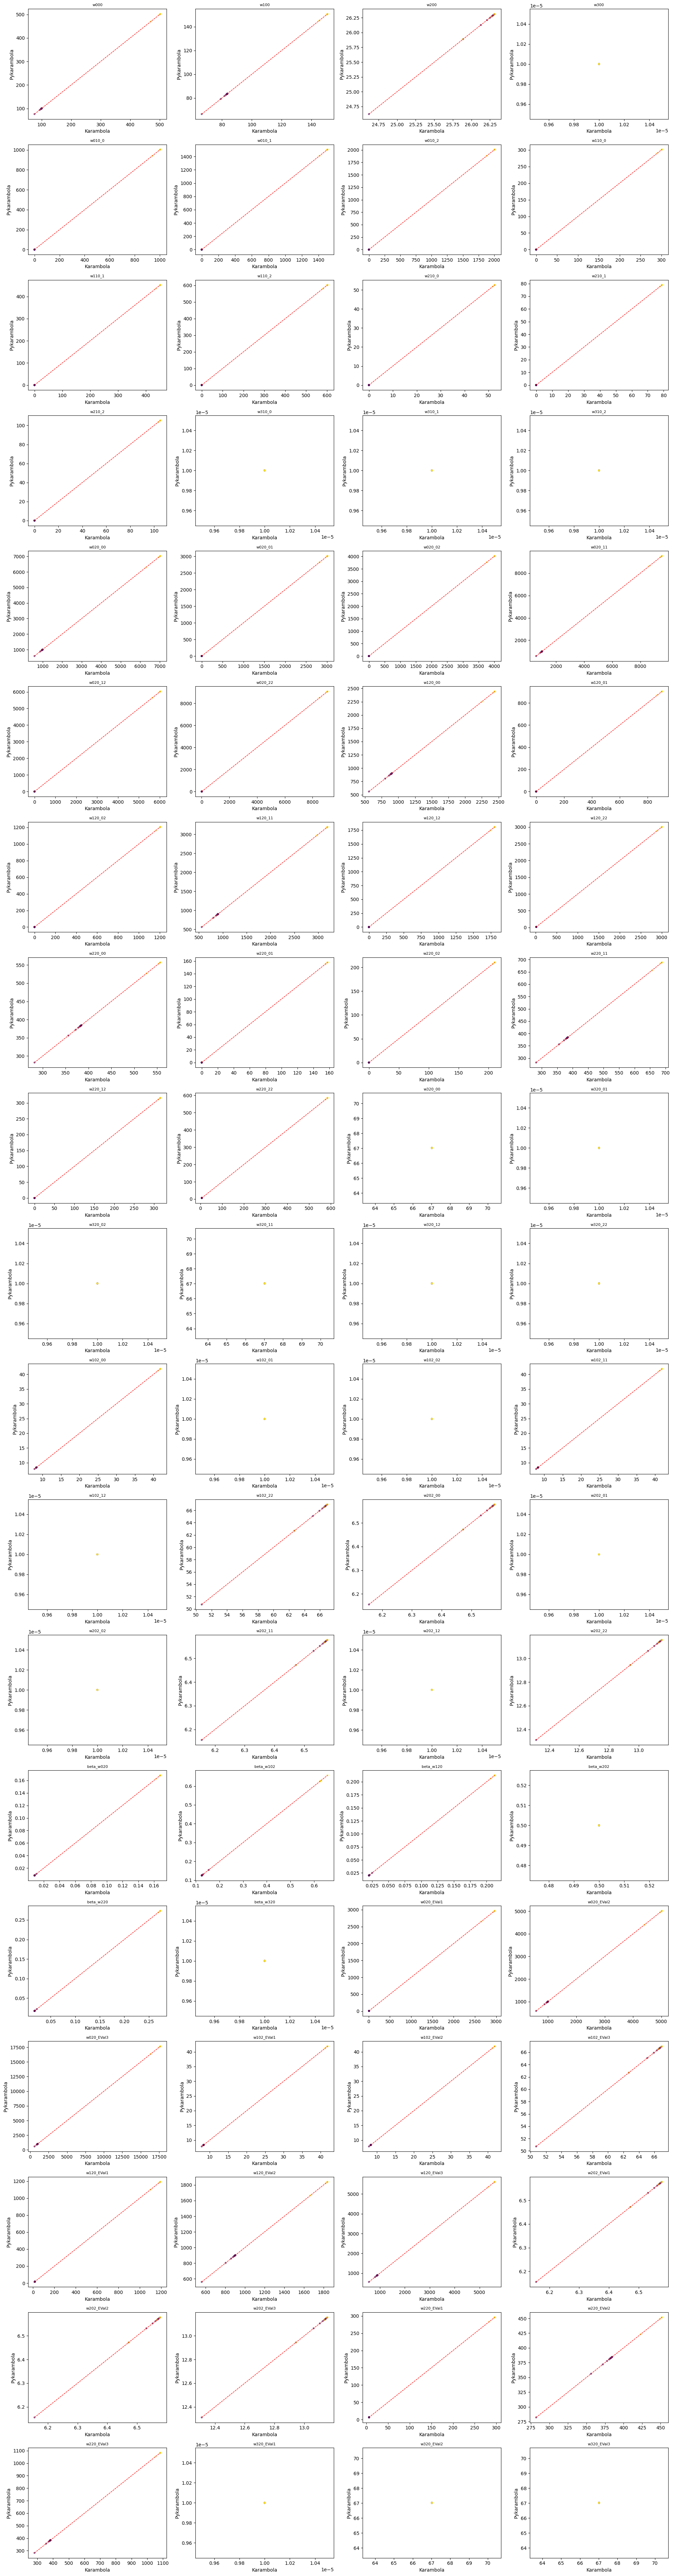

In [67]:
n = len(numeric_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flat

for ax, col in zip(axes, numeric_cols):
    x = df_merged[f'{col}_k']
    y = df_merged[f'{col}_py']
    ax.scatter(x, y, alpha=0.5, s=10, c=df_merged['label_mapped'].astype('category').cat.codes)
    # Perfect agreement line
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'r--', lw=1, label='y=x')
    ax.set_xlabel('Karambola'); ax.set_ylabel('Pykarambola')
    ax.set_title(col, fontsize=8)

for ax in axes:  # hide unused
    ax.set_visible(False)
plt.tight_layout()
plt.show()

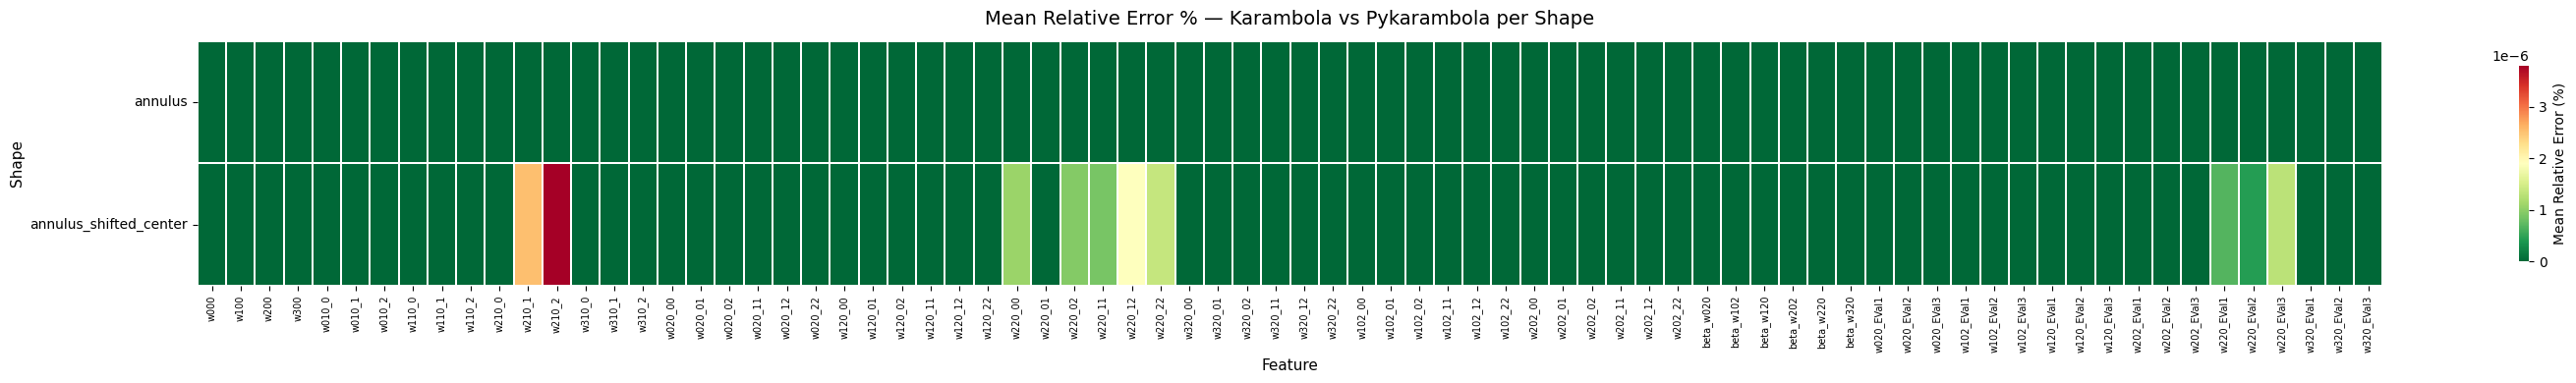

In [ ]:
# ── Step 2: Define numeric columns to compare ────────────────────────────────
# Select only float columns from the original df (before merge added suffixes)
numeric_cols = df.select_dtypes(include='float').columns.tolist()

# ── Step 3: Compute mean relative error per (shape, column) ──────────────────
heatmap_data = []

ABS_THRESHOLD = 1e-11   # values smaller than this are treated as effectively zero

for shape in df_merged['label_mapped'].unique():
    mask = df_merged['label_mapped'] == shape
    row = {'shape': shape}

    for col in numeric_cols:
        k_vals  = df_merged.loc[mask, f'{col}_k']
        py_vals = df_merged.loc[mask, f'{col}_py']

        abs_diff = (k_vals - py_vals).abs()

        # Build denominator: use karambola magnitude, but NaN-out rows where
        # BOTH values are negligibly small (numerically zero — not meaningful)
        denom = k_vals.abs()
        both_negligible = (k_vals.abs() <= ABS_THRESHOLD) & (py_vals.abs() <= ABS_THRESHOLD)
        denom[both_negligible] = np.nan   # will be excluded from mean
        denom = denom.replace(0, np.nan)  # avoid division by exact zero

        rel_error = abs_diff / denom * 100
        row[col] = rel_error.mean()       # nanmean behaviour: ignores NaNs

    heatmap_data.append(row)

# ── Step 4: Build heatmap DataFrame ──────────────────────────────────────────
# Rows = shapes, Columns = features, Values = mean relative error %
heatmap_df = (
    pd.DataFrame(heatmap_data)
    .set_index('shape')
    .fillna(0)
)


# ── Step 5: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(30, 4))

seaborn.heatmap(
    heatmap_df,
    annot=False,            # no numbers printed inside cells
    cmap='RdYlGn_r',        # red = high error, green = low error
    linewidths=0.3,         # thin grid lines between cells
    ax=ax,
    cbar_kws={
        'label': 'Mean Relative Error (%)',   # legend label
        'shrink': 0.8,                         # slightly shrink the colorbar
    }
)

ax.set_title('Mean Relative Error % — Karambola vs Pykarambola per Shape',
             fontsize=14, pad=12)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Shape',   fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.savefig('../plots/heatmap_relative_error_with_vectorization_basic_shapes_resolution.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
def parse_sub(image_num):
    m = re.search(r'_sub_(\d+)', image_num)
    return int(m.group(1)) if m else None

df_merged['sub'] = df_merged['image_num'].apply(parse_sub)

/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_31609/2399912336.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged['sub'] = df_merged['image_num'].apply(parse_sub)


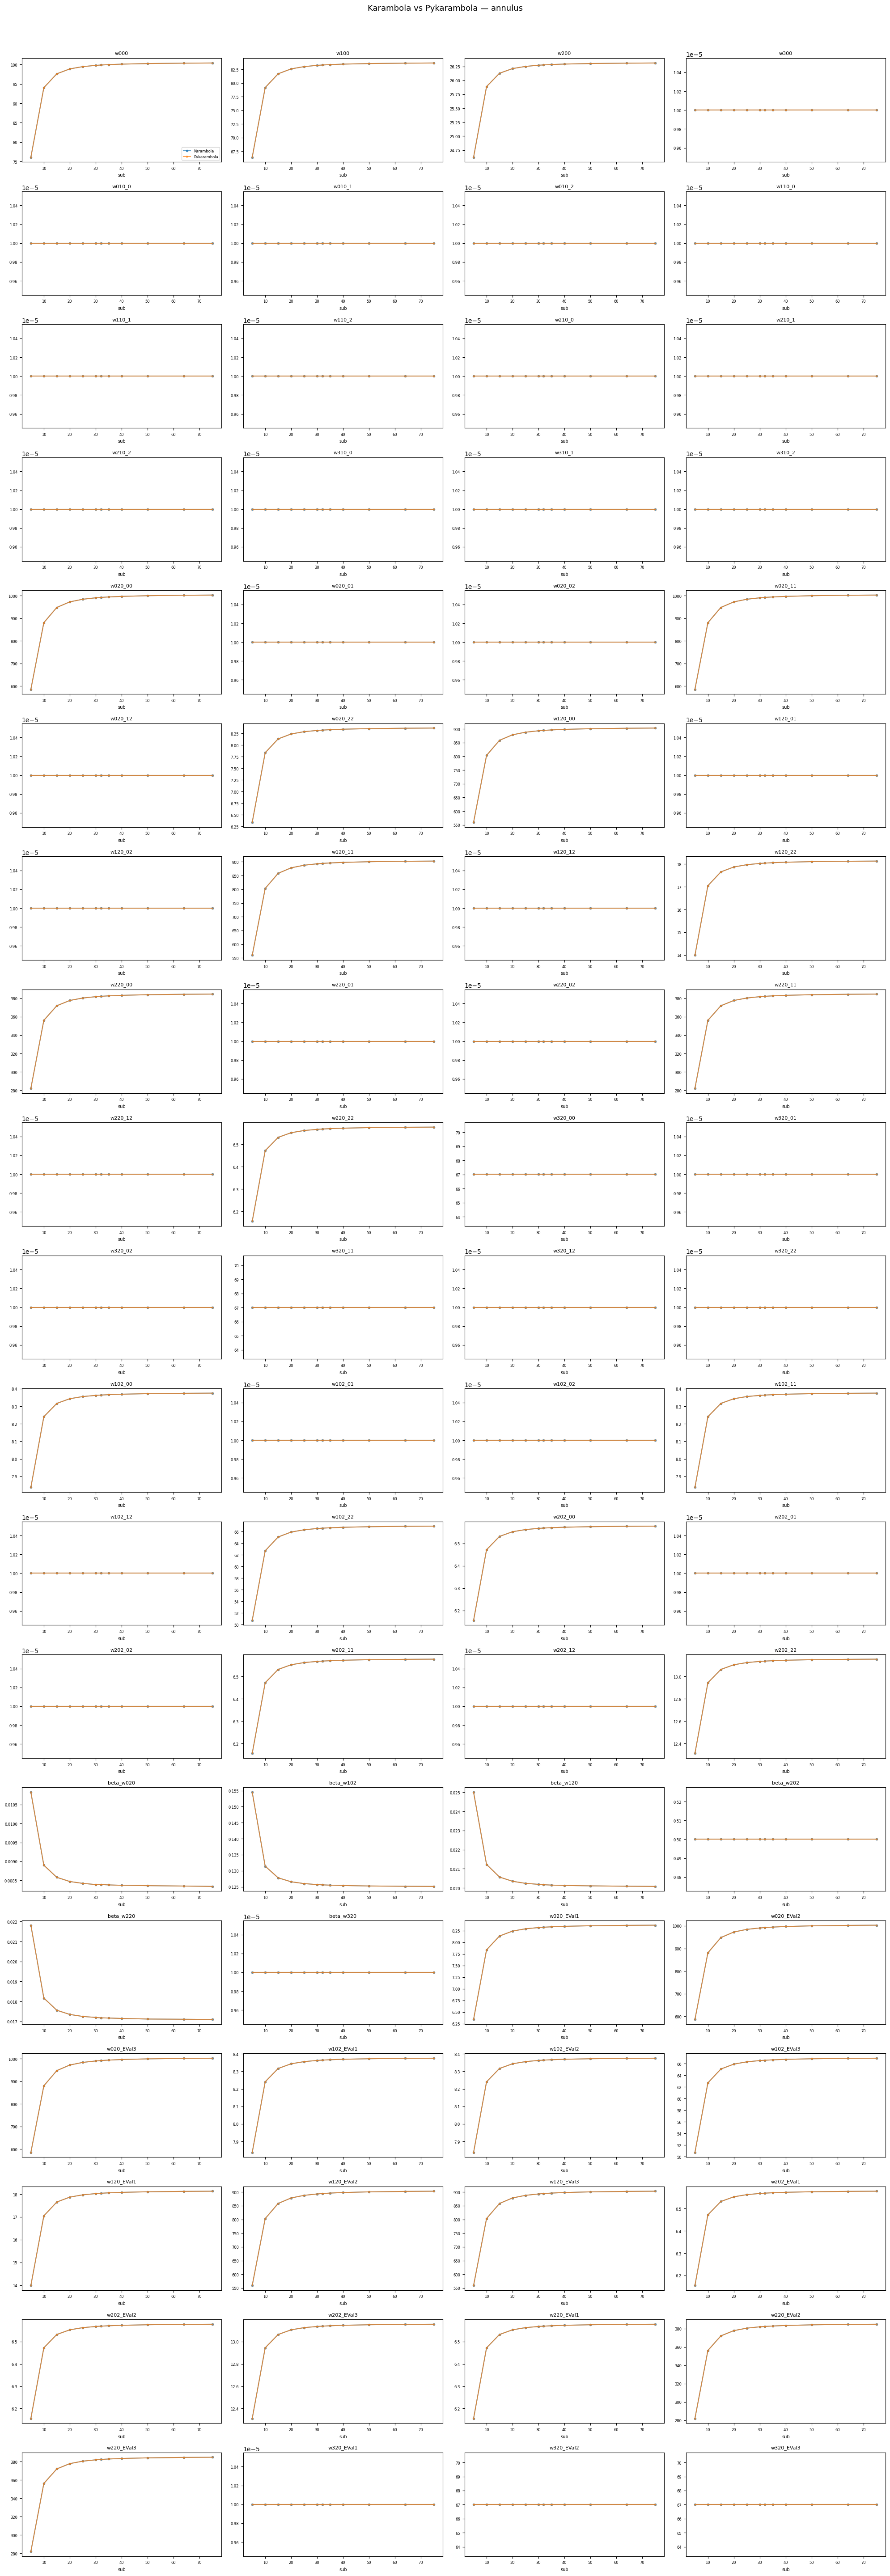

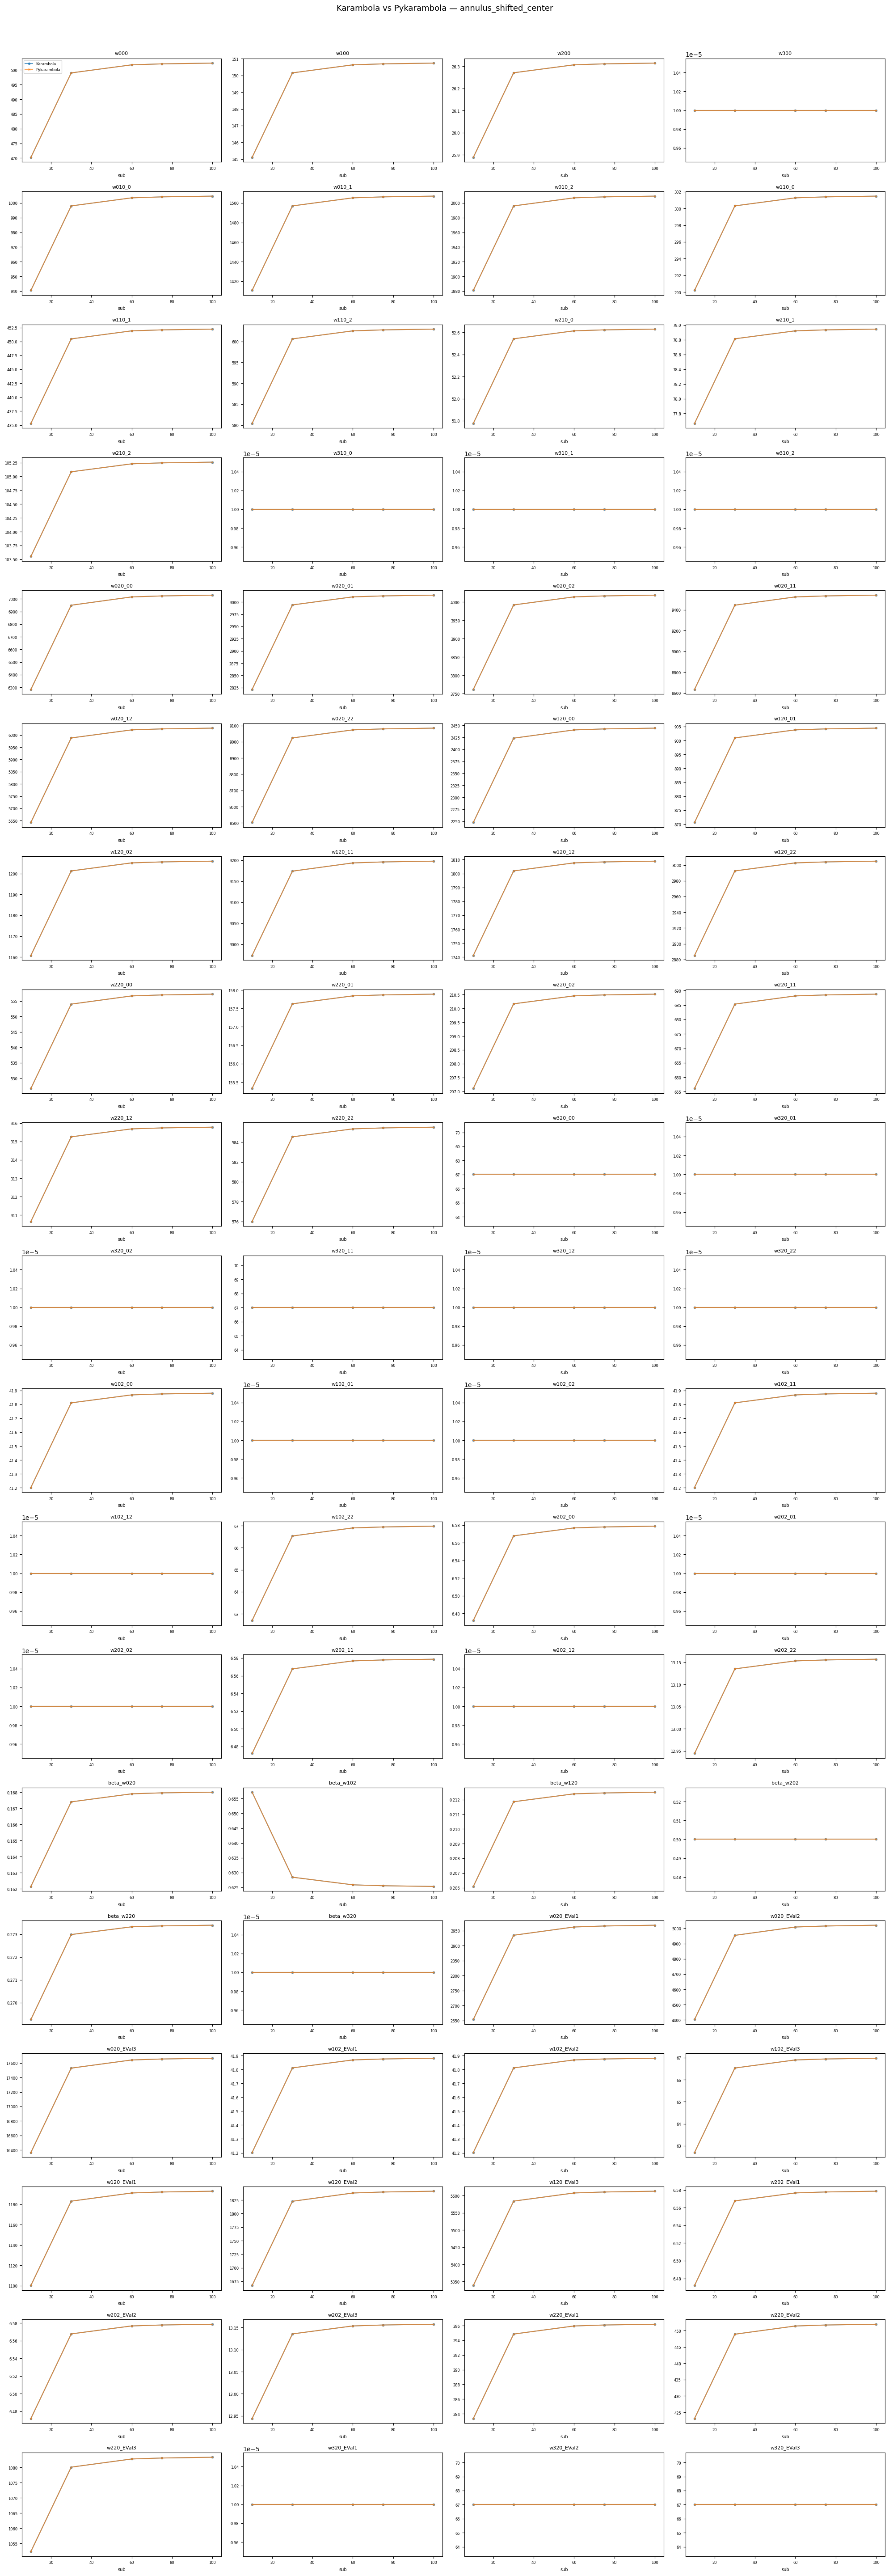

In [48]:
cols_to_plot = numeric_cols  # all float columns

for shape in df_merged['label_mapped'].unique():
    subset = df_merged[df_merged['label_mapped'] == shape].sort_values('sub')
    
    n_cols = 4
    n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
    axes = axes.flatten()
    
    for i, col in enumerate(cols_to_plot):
        axes[i].plot(subset['sub'], subset[f'{col}_k'],  marker='o', markersize=3, label='Karambola',   alpha=0.7)
        axes[i].plot(subset['sub'], subset[f'{col}_py'], marker='x', markersize=3, label='Pykarambola', alpha=0.7)
        axes[i].set_title(col, fontsize=8)
        axes[i].set_xlabel('sub', fontsize=7)
        axes[i].tick_params(labelsize=6)
        if i == 0:
            axes[i].legend(fontsize=6)
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'Karambola vs Pykarambola — {shape}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'sub_plot_{shape}.png', dpi=150, bbox_inches='tight')
    plt.show()